AIM: to perform Explolatory Data Analysis on the Covid 19 dataset

In [1]:
# Importing Libraries and data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"
)

print("Cases shape:", cases.shape)
print("Vaccination shape:", vax.shape)
cases.head()

Cases shape: (4692, 10)
Vaccination shape: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


In [3]:
# checking data type, null values and other information

print("Datatype in the dataset")
cases.dtypes


Datatype in the dataset


Date                          object
Name of State / UT            object
Latitude                     float64
Longitude                    float64
Total Confirmed cases        float64
Death                         object
Cured/Discharged/Migrated    float64
New cases                      int64
New deaths                     int64
New recovered                  int64
dtype: object

In [4]:
print("Total number of null values")
cases.isna().sum()


Total number of null values


Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [5]:
print("Number of unique state/UT names:", cases["Name of State / UT"].nunique())
sorted(cases["Name of State / UT"].unique())

Number of unique state/UT names: 40


['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Telangana***',
 'Telengana',
 'Tripura',
 'Union Territory of Chandigarh',
 'Union Territory of Jammu and Kashmir',
 'Union Territory of Ladakh',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [7]:
# Cleaning the data-Renaming snake-case column names
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",
]

# Fixing data types
cases["date"] = pd.to_datetime(cases["date"])
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)
cases["confirmed"] = cases["confirmed"].astype(int)
cases["cured"] = cases["cured"].astype(int)

# Fixing inconsistent state names
name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)

# Dropping any exact duplicate (date, state) rows this merge might create
cases = cases.drop_duplicates(subset=["date", "state"]).sort_values(["state", "date"]).reset_index(drop=True)

# A derived column: active cases = confirmed - deaths - recovered
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]

print("Clean state count:", cases["state"].nunique())
cases.dtypes

Clean state count: 35


date             datetime64[ns]
state                    object
lat                     float64
long                    float64
confirmed                 int64
deaths                    int64
cured                     int64
new_cases                 int64
new_deaths                int64
new_recovered             int64
active                    int64
dtype: object

In [8]:
cases.isna().sum()

date             0
state            0
lat              0
long             0
confirmed        0
deaths           0
cured            0
new_cases        0
new_deaths       0
new_recovered    0
active           0
dtype: int64

In [9]:
# Aggregating all state together, per data, using groupby

national = cases.groupby("date", as_index=False)[["confirmed", "deaths", "cured"]].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)
national["death_rate"] = (national["deaths"] / national["confirmed"] * 100).round(2)
national["new_confirmed"] = national["confirmed"].diff().fillna(national["confirmed"])

national.tail()

,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed
181,2020-08-02,1750723,37364,1145629,65.44,2.13,54735.0
182,2020-08-03,1803695,38135,1186203,65.77,2.11,52972.0
183,2020-08-04,1855745,38938,1230509,66.31,2.10,52050.0
184,2020-08-05,1908254,39795,1282215,67.19,2.09,52509.0
185,2020-08-06,1964536,40699,1328336,67.62,2.07,56282.0


In [10]:

latest_date = cases["date"].max()
latest_row = national.iloc[-1]

print(f"As of {latest_date.date()}:")
print(f"  Total confirmed : {latest_row['confirmed']:,}")
print(f"  Total recovered : {latest_row['cured']:,}")
print(f"  Total deaths    : {latest_row['deaths']:,}")
print(f"  Recovery rate   : {latest_row['recovery_rate']}%")
print(f"  Death rate      : {latest_row['death_rate']}%")

As of 2020-08-06:
  Total confirmed : 1,964,536
  Total recovered : 1,328,336
  Total deaths    : 40,699
  Recovery rate   : 67.62%
  Death rate      : 2.07%


In [11]:
# State wise summary
latest = cases[cases["date"] == latest_date].copy()
latest["recovery_rate"] = (latest["cured"] / latest["confirmed"] * 100).round(2)
latest["death_rate"] = (latest["deaths"] / latest["confirmed"] * 100).round(2)
latest = latest.sort_values("confirmed", ascending=False).reset_index(drop=True)

top10 = latest.head(10)

top10[["state", "confirmed", "deaths", "cured", "recovery_rate", "death_rate"]]

,state,confirmed,deaths,cured,recovery_rate,death_rate
0,Maharashtra,468265,16476,305521,65.25,3.52
1,Tamil Nadu,273460,4461,214815,78.55,1.63
2,Andhra Pradesh,186461,1681,104354,55.97,0.90
3,Karnataka,151449,2804,74679,49.31,1.85
4,Delhi,140232,4044,126116,89.93,2.88
5,Uttar Pradesh,104388,1857,60558,58.01,1.78
6,West Bengal,83800,1846,58962,70.36,2.20
7,Telangana,73050,589,52103,71.33,0.81
8,Gujarat,66669,2556,49433,74.15,3.83
9,Bihar,64770,355,42414,65.48,0.55


In [14]:
# forming a pivot table do we can see when each state's outbreak accelerated
cases["month"] = cases["date"].dt.strftime("%Y-%m")
month_pivot = cases[cases["state"].isin(top10["state"].head(5))].pivot_table(
    values="new_cases", index="state", columns="month", aggfunc="sum", fill_value=0
)
month_pivot

month,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,
Andhra Pradesh,39,1292,2237,10322,116666,55904
Delhi,96,3342,15110,66612,49242,5829
Karnataka,82,452,2387,11373,104337,32817
Maharashtra,218,9699,55253,104715,241915,56467
Tamil Nadu,73,2088,19022,65040,153754,33482


# Visualizing the cases

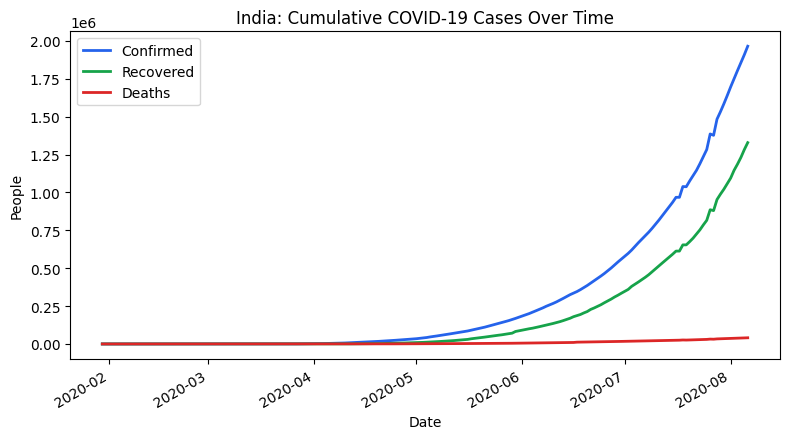

In [15]:
# chart 1-National cumulative trend
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["confirmed"], label="Confirmed", color="#2563eb", lw=2)
ax.plot(national["date"], national["cured"], label="Recovered", color="#16a34a", lw=2)
ax.plot(national["date"], national["deaths"], label="Deaths", color="#dc2626", lw=2)
ax.set_title("India: Cumulative COVID-19 Cases Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("People")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

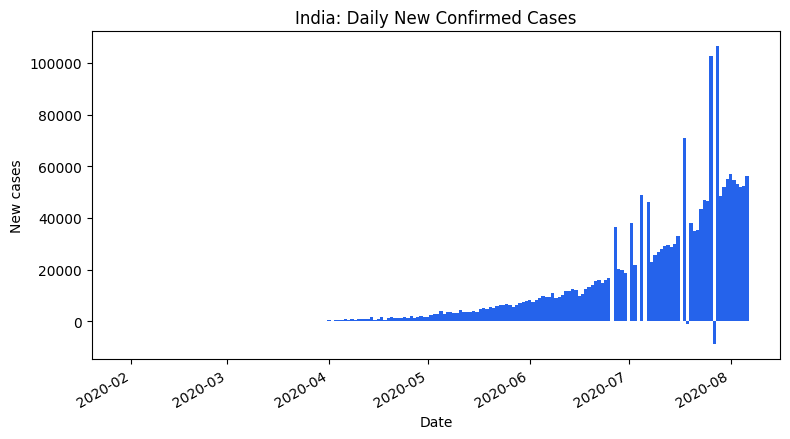

In [16]:
# Chart 2-Daily new confirmed cases

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(national["date"], national["new_confirmed"], color="#2563eb", width=1.0)
ax.set_title("India: Daily New Confirmed Cases")
ax.set_xlabel("Date"); ax.set_ylabel("New cases")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

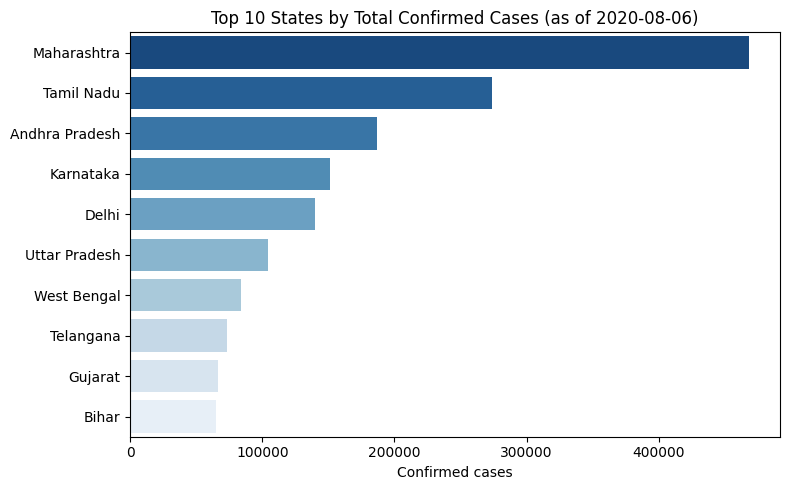

In [17]:
# chart 3- Top 10 states by total confirmed cases
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y="state", x="confirmed", hue="state", palette="Blues_r", legend=False, ax=ax)
ax.set_title(f"Top 10 States by Total Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

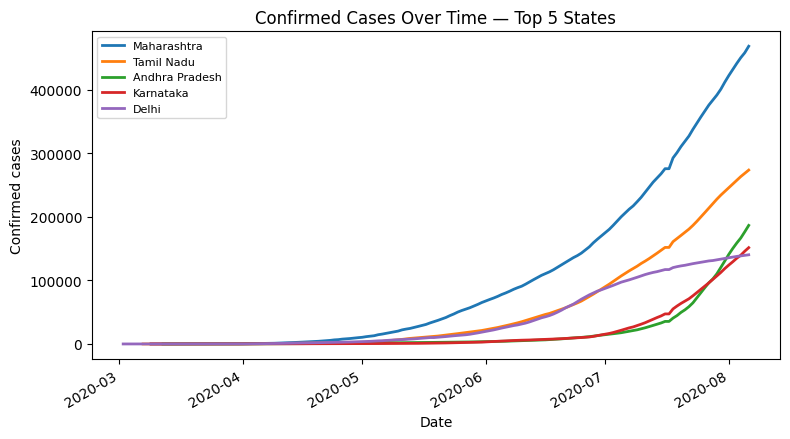

In [18]:
# chart 4-Recovery rate of the 10 worst-hit states

top5_states = top10["state"].head(5).tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
for s in top5_states:
    sub = cases[cases["state"] == s]
    ax.plot(sub["date"], sub["confirmed"], label=s, lw=2)
ax.set_title("Confirmed Cases Over Time — Top 5 States")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

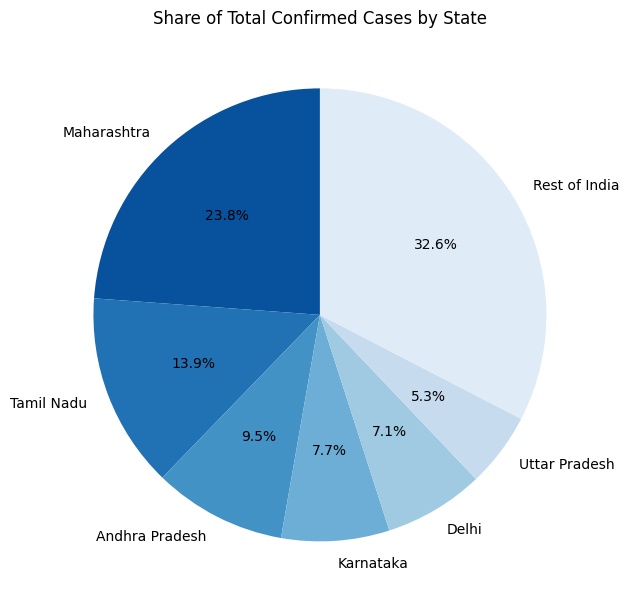

In [19]:
# chart 6- Share of national cases by state (pie chart)

top6 = latest.nlargest(6, "confirmed")[["state", "confirmed"]]
others = latest["confirmed"].sum() - top6["confirmed"].sum()
pie_labels = top6["state"].tolist() + ["Rest of India"]
pie_values = top6["confirmed"].tolist() + [others]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("Blues_r", 7))
ax.set_title("Share of Total Confirmed Cases by State")
plt.tight_layout()
plt.show()

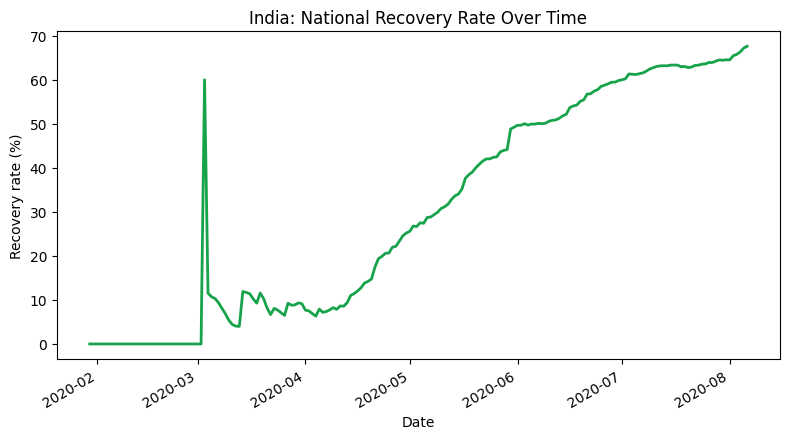

In [20]:
# chart 7- National recovery-rate trend
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["recovery_rate"], color="#16a34a", lw=2)
ax.set_title("India: National Recovery Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Recovery rate (%)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

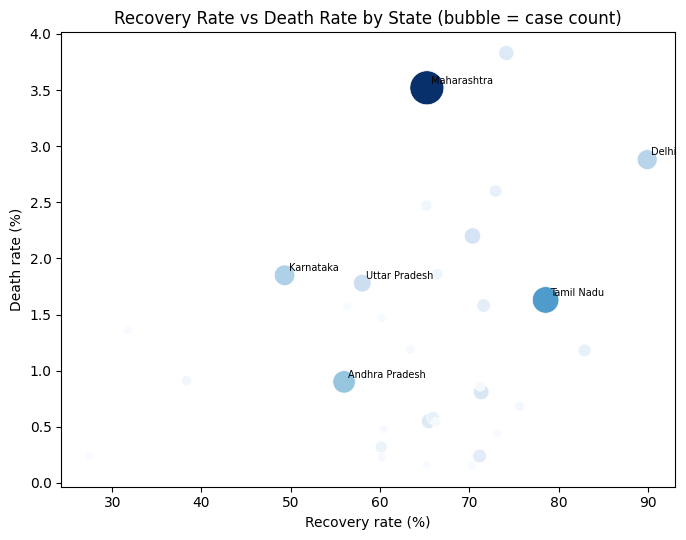

In [21]:
# Chart 8 — Recovery rate vs death rate, by state
# each bubble represents a case count

sizeable = latest[latest["confirmed"] >= 1000]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=sizeable, x="recovery_rate", y="death_rate", size="confirmed",
                 sizes=(40, 600), hue="confirmed", palette="Blues", legend=False, ax=ax)
for _, r in sizeable.nlargest(6, "confirmed").iterrows():
    ax.annotate(r["state"], (r["recovery_rate"], r["death_rate"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_title("Recovery Rate vs Death Rate by State (bubble = case count)")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("Death rate (%)")
plt.tight_layout()
plt.show()


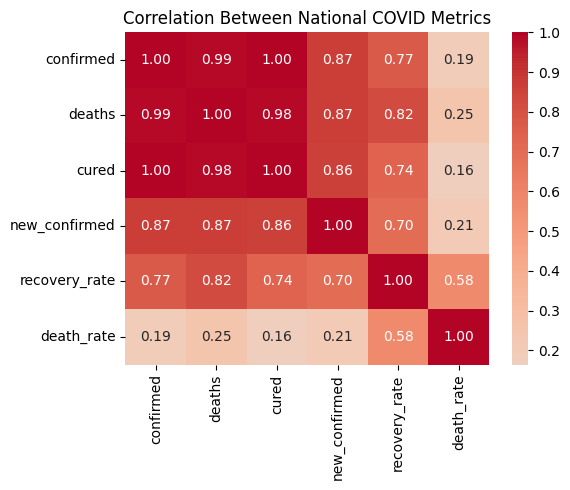

In [22]:
# Chart 9 — Correlation heatmap of national metrics

corr_cols = ["confirmed", "deaths", "cured", "new_confirmed", "recovery_rate", "death_rate"]
corr = national[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between National COVID Metrics")
plt.tight_layout()
plt.show()

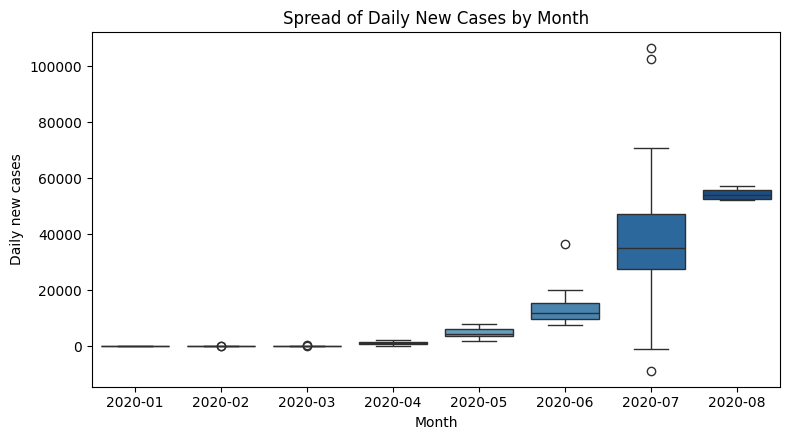

In [23]:
# Chart 10 — Spread of daily new cases, by month (boxplot)

national["month"] = national["date"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=national, x="month", y="new_confirmed", hue="month", palette="Blues", legend=False, ax=ax)
ax.set_title("Spread of Daily New Cases by Month")
ax.set_xlabel("Month"); ax.set_ylabel("Daily new cases")
plt.tight_layout()
plt.show()

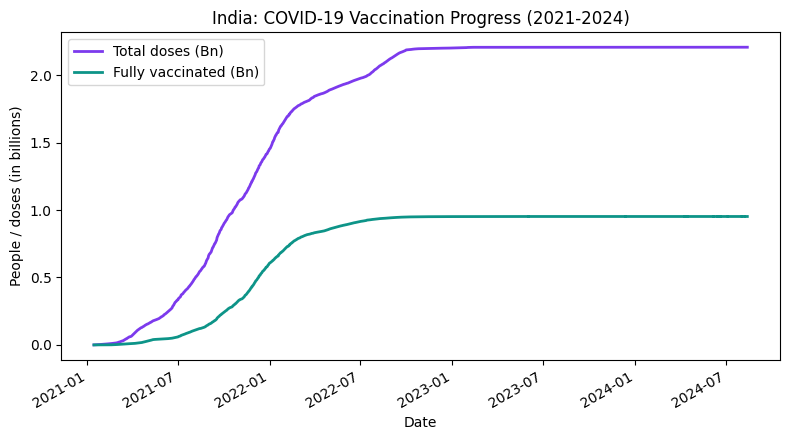

In [24]:
# Chart 11 — India's vaccination progress (2021-2024)

vax["date"] = pd.to_datetime(vax["date"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vax["date"], vax["total_vaccinations"] / 1e9, label="Total doses (Bn)", color="#7c3aed", lw=2)
ax.plot(vax["date"], vax["people_fully_vaccinated"] / 1e9, label="Fully vaccinated (Bn)", color="#0d9488", lw=2)
ax.set_title("India: COVID-19 Vaccination Progress (2021-2024)")
ax.set_xlabel("Date"); ax.set_ylabel("People / doses (in billions)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

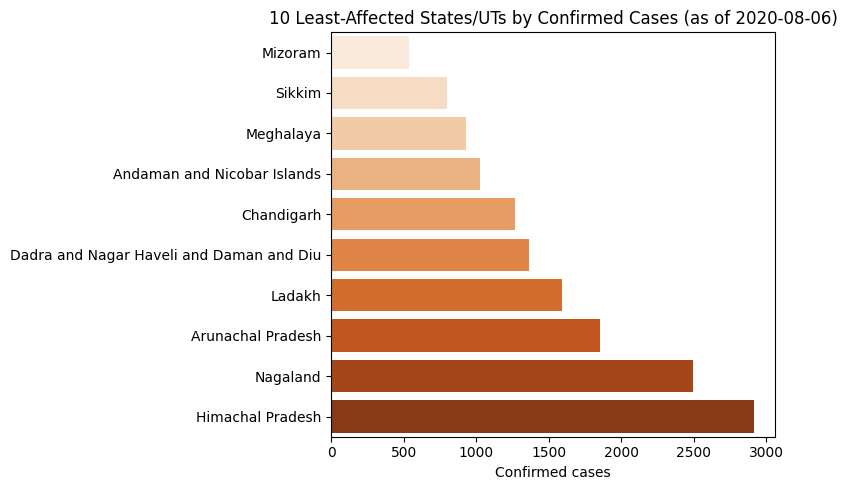

In [25]:
# Chart 12 — The 10 least-affected states/UTs
bottom10 = latest[latest["confirmed"] > 0].nsmallest(10, "confirmed")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=bottom10, y="state", x="confirmed", hue="state", palette="Oranges", legend=False, ax=ax)
ax.set_title(f"10 Least-Affected States/UTs by Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [26]:
cases.to_csv("cleaned_covid_india.csv", index=False)
print("Saved cleaned_covid_india.csv —", cases.shape[0], "rows.")

Saved cleaned_covid_india.csv — 4692 rows.


# Summary of the whole Analysis

**Coverage**
After standardizing duplicate spellings, the dataset includes 35 Indian states and Union Territories and covers 186 days, from 30 January 2020 to 6 August 2020, representing India's first COVID-19 wave.

**National Overview**
By the end of the observation period, India had reported approximately 19.6 lakh (1.96 million) confirmed cases, 13.3 lakh recoveries, and around 40,700 deaths. This corresponds to a national recovery rate of about 68% and a death rate of roughly 2.1%. However, daily new cases were still rising rapidly, reaching about 106,000 cases in a single day in late July 2020. This indicates that the first wave had not yet reached its peak when the dataset ended.

**Distribution Across States**
COVID-19 cases were distributed unevenly across the country. Maharashtra accounted for nearly one-fourth of India's total cases, followed by Tamil Nadu, Andhra Pradesh, Karnataka, and Delhi. The six states with the highest case counts together represented most of the country's total cases, showing that the outbreak was highly concentrated in particular regions rather than evenly distributed nationwide.

**Differences in Recovery Rates**
Recovery rates differed considerably between states. Delhi recorded a recovery rate of nearly 90%, considerably higher than that of several other heavily affected states. In contrast, Karnataka's recovery rate was still below 50% at the time of the snapshot. This may indicate that Karnataka's outbreak was at a relatively earlier or faster-growing stage, leaving less time for infected individuals to recover.

**Differences in Death Rates**
Fatality rates also showed substantial variation between states. Among the most severely affected states, Gujarat recorded the highest death rate, at nearly 3.8%, which was significantly above the national average. Meanwhile, states such as Bihar and Telangana reported rates below 1%. These differences could warrant further investigation into factors such as healthcare capacity, population age structure, and the extent of testing and case detection.

**Vaccination: The Next Phase**
India's COVID-19 vaccination campaign began in January 2021, several months after the case data in this dataset ended. By mid-2024, national records indicated that more than 2.2 billion vaccine doses had been administered and over 950 million people had been fully vaccinated. These figures demonstrate the large-scale public health response that followed the period covered by the dataset.

**Limitations**
The dataset is based on state-level government bulletins and therefore reflects differences and inconsistencies in reporting practices across states. These include variations in state-name spellings and formatting issues in the Death column that required cleaning. The recovery and death rates are calculated as simple ratios of cumulative reported totals and do not account for reporting delays or other time-related factors. As a result, these figures are better interpreted as broad trends rather than precise measures of clinical outcomes.